# Figure — R2 Performance: Full (N-matched, downsampled) vs Age >= 60 Cohort (paired bootstrap)

Grouped bar chart comparing bootstrap-estimated R2 (+/- 95% CI) for the PPG model
evaluated on the Age>=60 test stratum versus the full test set downsampled to the
SAME number of subjects (preserving the MAP distribution). Both arms share one
array of bootstrap resample positions, so the two CIs come from a genuinely
paired design -- unlike `Fig_Bootstrap_Age60_Comparison.ipynb`, which compares
unequal-sized, independent bootstraps.

Data source: `PERFORMANCE_RESULTS_PAPER / Bootstrap_AgeStratified_PairedDownsample /
{full_downsampled, age_gte60}`.

This is a branched, parallel analysis -- it does NOT read from or overwrite
`Bootstrap/ppg`, `Bootstrap/age_stratified/`, or the original
`Fig_Bootstrap_Age60_Comparison_{full,single}.png` figures.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path("../").resolve()))

from fig_style import (
    DPI, W_FULL, W_SINGLE, ASPECT, FONT_FAMILY,
    MIN_PX_FULL, MIN_PX_SINGLE,
    apply_base_style, save_fig,
)
from local_paths import PERFORMANCE_RESULTS_PAPER, FIGURES_PAPER

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FIG_OUT = FIGURES_PAPER
FIG_OUT.mkdir(parents=True, exist_ok=True)
print(f"Output directory : {FIG_OUT.resolve()}")
print(f"Full-page  : {W_FULL:.2f} x {W_FULL*ASPECT:.2f} in  ->"
      f"  {round(W_FULL*DPI)} x {round(W_FULL*ASPECT*DPI)} px @ {DPI} dpi")

Output directory : C:\Users\addp972\OneDrive - City, University of London\3.PhD\9. Experiments\2.LightGBM_SHAP\Figures_SummaryTables
Full-page  : 7.48 x 4.86 in  ->  3740 x 2431 px @ 500 dpi


## 1 - Config & data loading

In [2]:
METRIC  = "R2"
SCALE   = 100.0
TARGETS = ["SBP", "DBP", "MAP"]

BOOT_ROOT = PERFORMANCE_RESULTS_PAPER / "Bootstrap_AgeStratified_PairedDownsample"

MODELS = [
    {
        "key":   "full_downsampled",
        "label": "Full (N-matched)",
        "color": "#5D2E8C",   # purple, matches 'Original' in the source figure
    },
    {
        "key":   "age_gte60",
        "label": "Age \u226560",
        "color": "#F1E8B8",   # amber, matches the source figure
    },
]

BAR_W = 0.35


def load_ci(model_key: str, target: str) -> tuple:
    """Return (point_estimate, ci_lower, ci_upper) scaled to %.

    Note: unlike Bootstrap/{...}/CI_{target}.csv (semicolon-delimited on disk),
    these new files are written by eval.save_bootstrap_ci with pandas' default
    comma separator -- read accordingly.
    """
    path = BOOT_ROOT / model_key / f"CI_{target}.csv"
    df   = pd.read_csv(path)
    row  = df[df["metric"] == METRIC].iloc[0]
    return (
        float(row["point_estimate"]) * SCALE,
        float(row["ci_lower"])       * SCALE,
        float(row["ci_upper"])       * SCALE,
    )


# Pre-load all CI values
ci_table = {}
for model in MODELS:
    ci_table[model["key"]] = {}
    for target in TARGETS:
        pt, lo, hi = load_ci(model["key"], target)
        ci_table[model["key"]][target] = (pt, lo, hi)
        print(f"  {model['key']:20s}  {target}: {pt:.2f}%  95% CI [{lo:.2f}%, {hi:.2f}%]")

# Pre-load MDE / equivalence verdicts (paired) for the figure footnote
mde_df = pd.read_csv(BOOT_ROOT / "MDE_Equivalence_AgeStratified_PairedDownsample.csv")
equivalence = {row["target"]: bool(row["equivalent"]) for _, row in mde_df.iterrows()}
mde_pp      = {row["target"]: float(row["mde_pp"])    for _, row in mde_df.iterrows()}
print()
print(mde_df[["target", "observed_diff_pp", "mde_pp", "ci90_lower_pp", "ci90_upper_pp", "equivalent"]]
      .to_string(index=False))

  full_downsampled      SBP: 18.78%  95% CI [9.76%, 26.73%]
  full_downsampled      DBP: 22.42%  95% CI [12.06%, 31.26%]
  full_downsampled      MAP: 27.06%  95% CI [16.70%, 35.50%]
  age_gte60             SBP: 16.52%  95% CI [7.77%, 24.29%]
  age_gte60             DBP: 13.81%  95% CI [4.42%, 21.79%]
  age_gte60             MAP: 21.76%  95% CI [11.96%, 29.97%]

target  observed_diff_pp    mde_pp  ci90_lower_pp  ci90_upper_pp  equivalent
   SBP         -2.253389 17.502480     -11.965153       8.541804       False
   DBP         -8.610625 20.187530     -20.097374       4.008169       False
   MAP         -5.302772 20.412485     -16.833029       6.833191       False


## 2 - Plot

Full-page  : 3740 x 2431 px
Single-col : 1770 x 1150 px


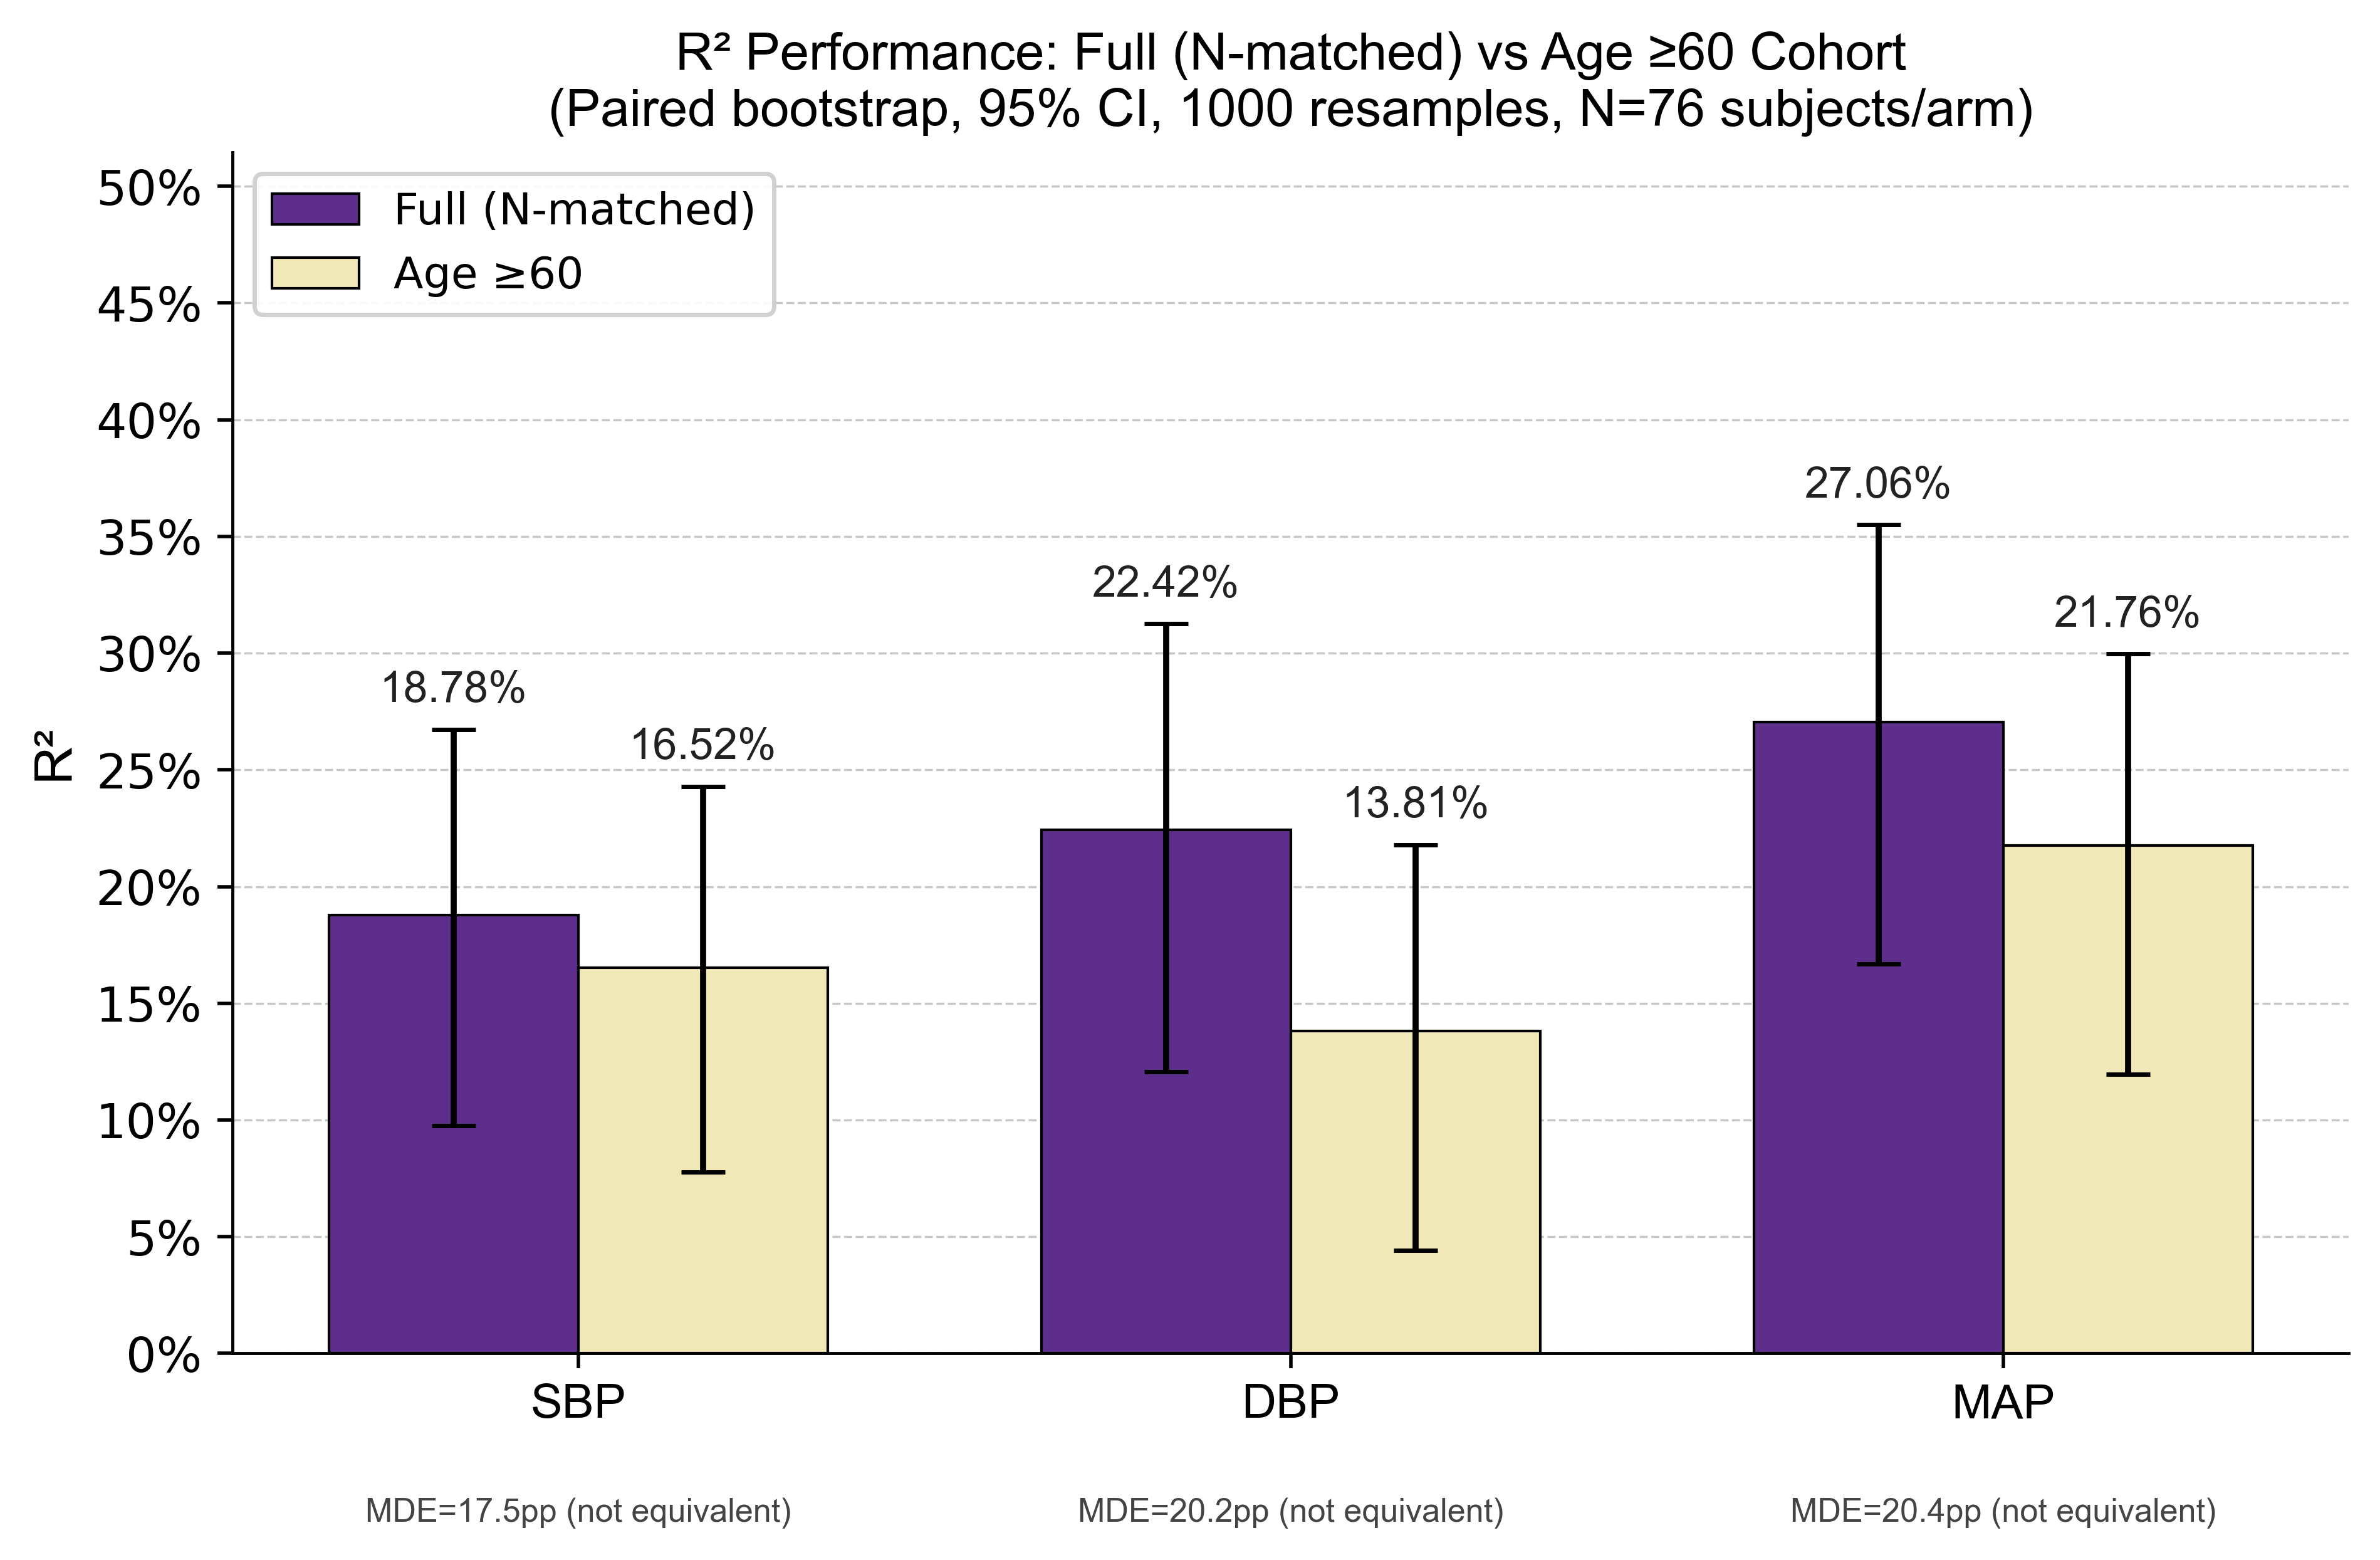

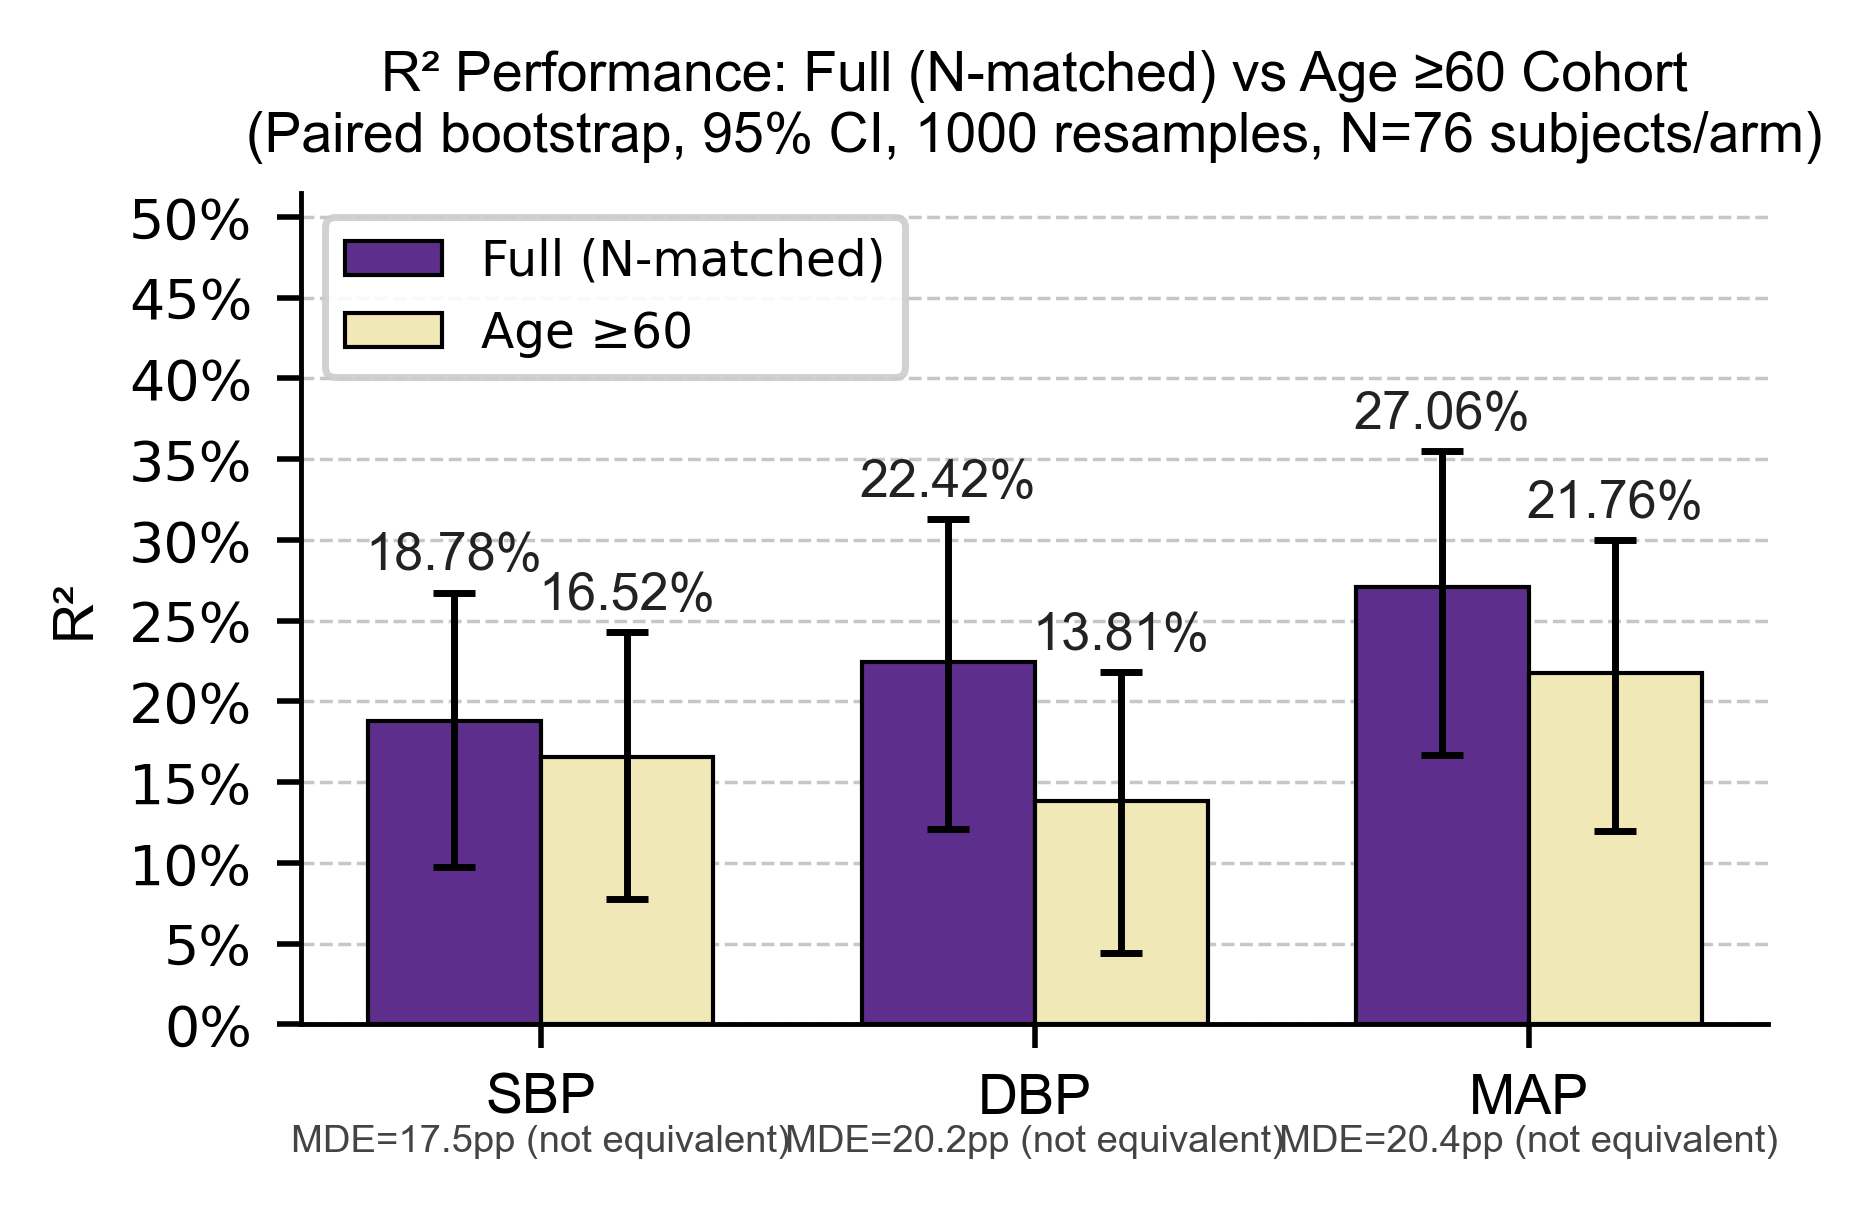

In [3]:
x       = np.arange(len(TARGETS))
offsets = [-BAR_W / 2, BAR_W / 2]


def make_fig(width_in: float):
    is_small = width_in < 5
    label_fs = 7.5 if is_small else 10.0
    tick_fs  = 8   if is_small else 11
    title_fs = 8   if is_small else 12
    leg_fs   = 7   if is_small else 10
    cap_sz   = 3   if is_small else 5
    err_lw   = 1.0 if is_small else 1.4
    note_fs  = 5.5 if is_small else 7.5

    height_in = width_in * ASPECT
    fig, ax = plt.subplots(
        figsize=(width_in, height_in), dpi=DPI, layout="constrained"
    )

    all_uppers = []

    for model, offset in zip(MODELS, offsets):
        pts      = [ci_table[model["key"]][t][0] for t in TARGETS]
        lows     = [ci_table[model["key"]][t][0] - ci_table[model["key"]][t][1] for t in TARGETS]  # pt - lo
        highs    = [ci_table[model["key"]][t][2] - ci_table[model["key"]][t][0] for t in TARGETS]  # hi - pt
        ci_upper = [ci_table[model["key"]][t][2] for t in TARGETS]
        all_uppers.extend(ci_upper)

        # Bars
        ax.bar(
            x + offset, pts, BAR_W,
            color=model["color"], label=model["label"],
            edgecolor="black", linewidth=0.6, zorder=3,
        )

        # Asymmetric error bars
        ax.errorbar(
            x + offset, pts,
            yerr=[lows, highs],
            fmt="none", color="black",
            capsize=cap_sz, linewidth=err_lw, zorder=4,
        )

        # Point estimate labels above the CI upper bound
        for i, (pt, hi_abs) in enumerate(zip(pts, ci_upper)):
            ax.text(
                x[i] + offset, hi_abs + 0.8,
                f"{pt:.2f}%",
                ha="center", va="bottom",
                fontsize=label_fs, fontfamily=FONT_FAMILY,
                color="#222222",
            )

    # Equivalence verdict labels under each target's x-tick
    for i, t in enumerate(TARGETS):
        verdict = "equivalent" if equivalence[t] else "not equivalent"
        ax.text(
            x[i], -0.12, f"MDE={mde_pp[t]:.1f}pp ({verdict})",
            ha="center", va="top", transform=ax.get_xaxis_transform(),
            fontsize=note_fs, fontfamily=FONT_FAMILY, color="#444444",
        )

    # Axes
    y_max = max(all_uppers)
    ax.set_ylim(0, y_max * 1.45)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.set_xticks(x)
    ax.set_xticklabels(TARGETS, fontsize=tick_fs, fontfamily=FONT_FAMILY)
    ax.set_ylabel("R\u00b2", fontsize=title_fs, fontfamily=FONT_FAMILY)

    ax.legend(
        loc="upper left", fontsize=leg_fs,
        frameon=True, framealpha=0.9, edgecolor="#CCCCCC",
    )

    ax.set_title(
        "R\u00b2 Performance: Full (N-matched) vs Age \u226560 Cohort\n"
        "(Paired bootstrap, 95% CI, 1000 resamples, N=" + str(len(pd.read_csv(BOOT_ROOT / 'Downsampled_Test_Subjects.csv'))) + " subjects/arm)",
        fontsize=title_fs, fontfamily=FONT_FAMILY, pad=6,
    )

    apply_base_style(ax, grid_axis="y")
    ax.tick_params(axis="both", labelsize=tick_fs)
    return fig


fig_full   = make_fig(W_FULL)
fig_single = make_fig(W_SINGLE)

save_fig(fig_full,   "Fig_Bootstrap_Age60_Comparison_PairedDownsample_full",   FIG_OUT)
save_fig(fig_single, "Fig_Bootstrap_Age60_Comparison_PairedDownsample_single", FIG_OUT)

print(f"Full-page  : {round(W_FULL*DPI)} x {round(W_FULL*ASPECT*DPI)} px")
print(f"Single-col : {round(W_SINGLE*DPI)} x {round(W_SINGLE*ASPECT*DPI)} px")
plt.show()

## 3 - Verify pixel counts and confirm the original figure is untouched

In [4]:
from PIL import Image

for fname, req_w in [
    ("Fig_Bootstrap_Age60_Comparison_PairedDownsample_full.png",   MIN_PX_FULL),
    ("Fig_Bootstrap_Age60_Comparison_PairedDownsample_single.png", MIN_PX_SINGLE),
]:
    with Image.open(FIG_OUT / fname) as im:
        w, h = im.size
    ok = "OK" if w >= req_w else "FAIL"
    print(f"[{ok}] {fname}: {w} x {h} px  (min required: {req_w} px wide)")

# Sanity: confirm this run did not touch the ORIGINAL figure files.
import os, time
for fname in ["Fig_Bootstrap_Age60_Comparison_full.png", "Fig_Bootstrap_Age60_Comparison_single.png"]:
    p = FIG_OUT / fname
    if p.exists():
        mtime = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(os.path.getmtime(p)))
        print(f"[untouched check] {fname}: last modified {mtime}")
    else:
        print(f"[untouched check] {fname}: not found (nothing to compare)")

[OK] Fig_Bootstrap_Age60_Comparison_PairedDownsample_full.png: 3798 x 2488 px  (min required: 3740 px wide)
[OK] Fig_Bootstrap_Age60_Comparison_PairedDownsample_single.png: 1871 x 1209 px  (min required: 1772 px wide)
[untouched check] Fig_Bootstrap_Age60_Comparison_full.png: last modified 2026-06-26 16:30:43
[untouched check] Fig_Bootstrap_Age60_Comparison_single.png: last modified 2026-06-26 16:30:44
